# Cat vs Dog Image Classification using CNN and VGG16

## Objective
The objective of this project is to classify images of cats and dogs using Deep Learning techniques.

The notebook implements two approaches:

1. A Convolutional Neural Network (CNN) built from scratch.
2. Transfer Learning using the pretrained VGG16 model.

The performance of both models is compared using accuracy and a confusion matrix.

In [19]:
import os

os.chdir("/Users/tanushak/Cat_Dog")
print(os.getcwd())

/Users/tanushak/Cat_Dog


In [20]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPool2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    Rescaling
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import numpy as np
import os
import warnings

warnings.filterwarnings("ignore")

### Prepare the Dataset

In [22]:
import os
import shutil
import random

random.seed(42)

base_dir = "dataset"

train_dir = "train"
test_dir = "test"
valid_dir = "valid"

for folder in [train_dir, test_dir, valid_dir]:
    if os.path.exists(folder):
        shutil.rmtree(folder)

for x in [train_dir, test_dir, valid_dir]:
    for y in ["Cat", "Dog"]:
        os.makedirs(os.path.join(x, y), exist_ok=True)

for y in ["Cat", "Dog"]:
    src = os.path.join(base_dir, y)

    img = [
        i for i in os.listdir(src)
        if i.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    random.shuffle(img)

    train_img = img[:500]
    test_img = img[500:600]
    valid_img = img[600:650]

    for i in train_img:
        shutil.copy(os.path.join(src, i), os.path.join(train_dir, y, i))

    for i in test_img:
        shutil.copy(os.path.join(src, i), os.path.join(test_dir, y, i))

    for i in valid_img:
        shutil.copy(os.path.join(src, i), os.path.join(valid_dir, y, i))

In [24]:
train_path = "train"
valid_path = "valid"
test_path = "test"

In [25]:
import os

print("Train folders:", os.listdir("train"))

print("Cat images:", len(os.listdir("train/Cat")))
print("Dog images:", len(os.listdir("train/Dog")))

Train folders: ['Cat', 'Dog']
Cat images: 500
Dog images: 500


### Create Image Generators

In [26]:
train_batch = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(directory=train_path, target_size=(224,224), classes=["Cat", "Dog"], batch_size=10)
test_batch = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(directory=test_path, target_size=(224,224), classes=["Cat", "Dog"], batch_size=10, shuffle=False)
valid_batch = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(directory=valid_path, target_size=(224,224), classes=["Cat", "Dog"], batch_size=10)

Found 1000 images belonging to 2 classes.


Found 200 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


In [27]:
imgs, labels = next(train_batch)

### Visualize Sample Images

In [28]:
def plotImg(img_arr):
    fig, axes = plt.subplots(1, 10, figsize=(20,20))
    axes = axes.flatten()
    for i, ax in zip(img_arr, axes):
        ax.imshow(i)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-116.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..96.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-110.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..150.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-112.68..136.061].
Clipping input data t

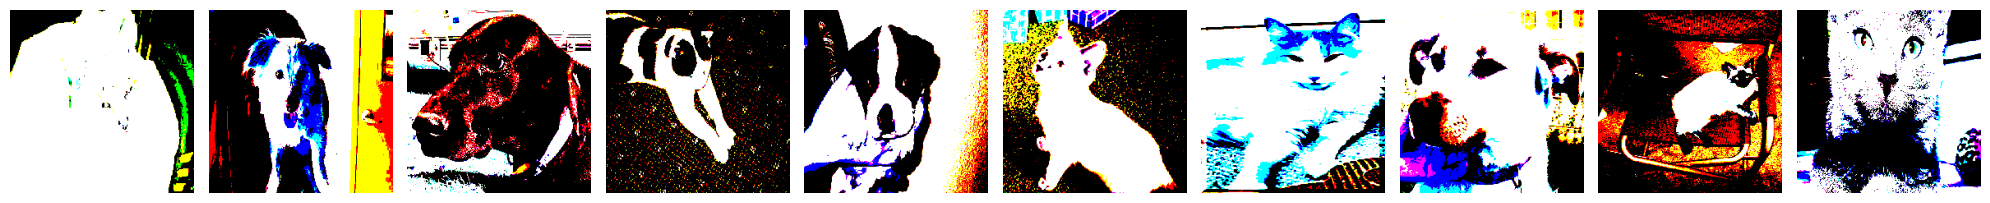

[[1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]]


In [29]:
plotImg(imgs)
print(labels)

# Part 1: Convolutional Neural Network (CNN)

A simple CNN is built from scratch using:

- Convolution layers
- Max Pooling layers
- Flatten layer
- Dense output layer

This model serves as the baseline for comparison.

In [30]:
model = Sequential([
    Conv2D(filters=32, kernel_size=(3,3), activation="relu", padding="same", input_shape=(224,224,3)), MaxPool2D(pool_size=(2,2), strides=2),
    Conv2D(filters=64, kernel_size=(3,3), activation="relu", padding="same"), MaxPool2D(pool_size=(2,2), strides=2), 
    Flatten(),
    Dense(units=2, activation='softmax'),
])

### CNN Architecture

Display the model architecture, layer configuration, and trainable parameters.

In [31]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │       401,410 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 420,802 (1.61 MB)

 Trainable params: 420,802 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss="categorical_crossentropy", metrics = ["accuracy"])

### Train the CNN

Train the CNN using the training dataset while monitoring validation accuracy after each epoch.

In [33]:
history = model.fit(
    train_batch,
    validation_data=valid_batch,
    epochs=10,
    verbose=2
)

Epoch 1/10
100/100 - 14s - 135ms/step - accuracy: 0.5420 - loss: 16.5925 - val_accuracy: 0.5700 - val_loss: 7.9306
Epoch 2/10
100/100 - 12s - 118ms/step - accuracy: 0.7690 - loss: 2.2551 - val_accuracy: 0.6300 - val_loss: 5.3796
Epoch 3/10
100/100 - 12s - 116ms/step - accuracy: 0.8920 - loss: 0.4551 - val_accuracy: 0.5500 - val_loss: 3.7582
Epoch 4/10
100/100 - 12s - 116ms/step - accuracy: 0.9520 - loss: 0.2075 - val_accuracy: 0.4800 - val_loss: 3.8510
Epoch 5/10
100/100 - 12s - 116ms/step - accuracy: 0.9870 - loss: 0.0358 - val_accuracy: 0.5700 - val_loss: 2.9257
Epoch 6/10
100/100 - 12s - 118ms/step - accuracy: 0.9930 - loss: 0.0206 - val_accuracy: 0.6500 - val_loss: 3.3673
Epoch 7/10
100/100 - 12s - 117ms/step - accuracy: 0.9950 - loss: 0.0103 - val_accuracy: 0.5600 - val_loss: 3.2012
Epoch 8/10
100/100 - 12s - 117ms/step - accuracy: 0.9980 - loss: 0.0062 - val_accuracy: 0.6300 - val_loss: 3.0258
Epoch 9/10
100/100 - 12s - 116ms/step - accuracy: 1.0000 - loss: 2.5243e-04 - val_accur

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-110.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..139.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-113.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-122.68..136.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-97.939..130.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-121.68..151.061].
Clipping input data 

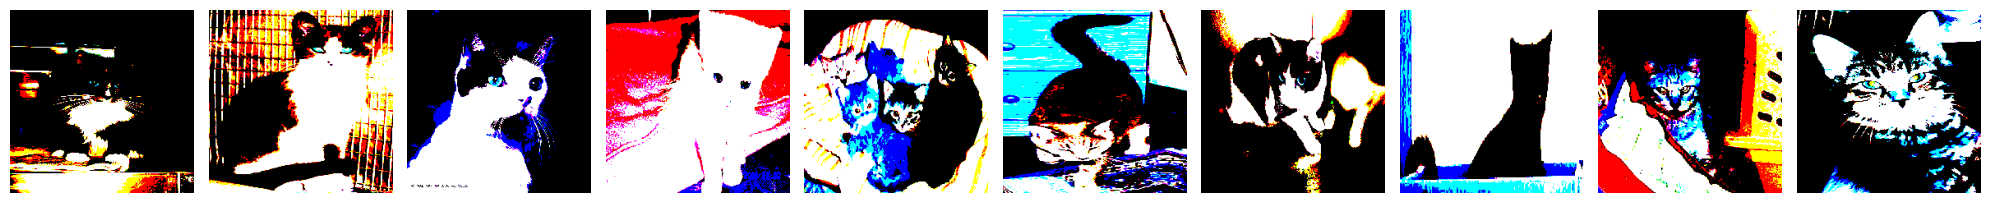

[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [34]:
test_imgs, test_labels = next(test_batch)
plotImg(test_imgs)
print(test_labels)

In [ ]:
test_batch.classes

In [36]:
predictions = model.predict(x=test_batch, verbose=0)

In [ ]:
np.round(predictions)

### Evaluate CNN Performance

Generate predictions on the test dataset and visualize the confusion matrix to evaluate classification performance.

In [39]:
import itertools
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues):

    plt.figure(figsize=(6,6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.

    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], '.2f' if normalize else 'd'),
                 horizontalalignment='center',
                 color='white' if cm[i, j] > thresh else 'black')

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()

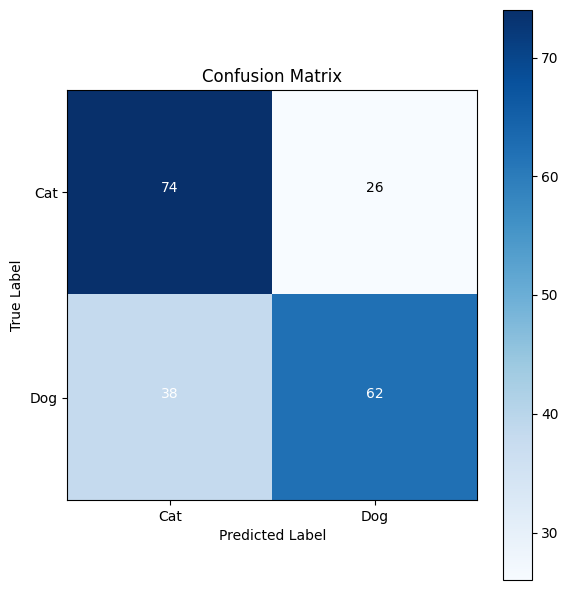

In [40]:
plot_confusion_matrix(
    cm,
    classes=["Cat", "Dog"],
    title="Confusion Matrix"
)

# Part 2: Transfer Learning using VGG16

Instead of training a network from scratch, Transfer Learning uses a pretrained VGG16 model trained on the ImageNet dataset.

Only the final classification layer is replaced to adapt the model for binary classification.

### Load the Pretrained VGG16 Model

Load the VGG16 architecture with pretrained ImageNet weights.

In [41]:
vgg16_model = tf.keras.applications.vgg16.VGG16()

In [42]:
vgg16_model.summary() #Inspect original pretrained VGG16 architecture

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

### Modify the VGG16 Architecture

Remove the original ImageNet classification layer while retaining the learned feature extraction layers.

In [43]:
model=Sequential()
for layer in  vgg16_model.layers[:-1]:
    model.add(layer)

In [44]:
model.summary() #last layer is removed

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,260,544 (512.16 MB)

 Trainable params: 134,260,544 (512.16 MB)

 Non-trainable params: 0 (0.00 B)

### Add a New Output Layer

Replace the original classifier with a Dense layer containing two output neurons for Cat and Dog classification.

### Freeze Pretrained Layers

Freeze all pretrained VGG16 layers so that only the newly added classification layer is trained.

In [45]:
model.add(Dense(units=2, activation="softmax"))
# Freeze all pretrained VGG16 layers
for layer in model.layers[:-1]:
    layer.trainable = False

In [46]:
for layer in model.layers:
    print(layer.name, layer.trainable)

block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 False
block5_conv2 False
block5_conv3 False
block5_pool False
flatten False
fc1 False
fc2 False
dense_2 True


In [47]:
model.summary() #gives summary of cats v/s Dogs - Verify new classifier was added

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,268,738 (512.19 MB)

 Trainable params: 8,194 (32.01 KB)

 Non-trainable params: 134,260,544 (512.16 MB)

In [48]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss="categorical_crossentropy", metrics = ["accuracy"])

### Reload Image Generators

Recreate the image generators to ensure the correct dataset paths are used during VGG16 training.

In [50]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_batch = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.vgg16.preprocess_input
).flow_from_directory(
    "train",
    target_size=(224,224),
    classes=["Cat","Dog"],
    batch_size=10
)

valid_batch = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.vgg16.preprocess_input
).flow_from_directory(
    "valid",
    target_size=(224,224),
    classes=["Cat","Dog"],
    batch_size=10
)

test_batch = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.vgg16.preprocess_input
).flow_from_directory(
    "test",
    target_size=(224,224),
    classes=["Cat","Dog"],
    batch_size=10,
    shuffle=False
)

Found 1000 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


### Train the VGG16 Model

Train the modified VGG16 model using transfer learning and compare its performance with the custom CNN.

In [51]:
history = model.fit(
    train_batch,
    validation_data=valid_batch,
    epochs=3,
    verbose=2
)

Epoch 1/3
100/100 - 114s - 1s/step - accuracy: 0.8050 - loss: 0.4637 - val_accuracy: 0.9300 - val_loss: 0.1800
Epoch 2/3
100/100 - 107s - 1s/step - accuracy: 0.9710 - loss: 0.0909 - val_accuracy: 0.9400 - val_loss: 0.1367
Epoch 3/3
100/100 - 108s - 1s/step - accuracy: 0.9830 - loss: 0.0568 - val_accuracy: 0.9700 - val_loss: 0.1203


### Training Accuracy

Visualize training and validation accuracy across epochs.

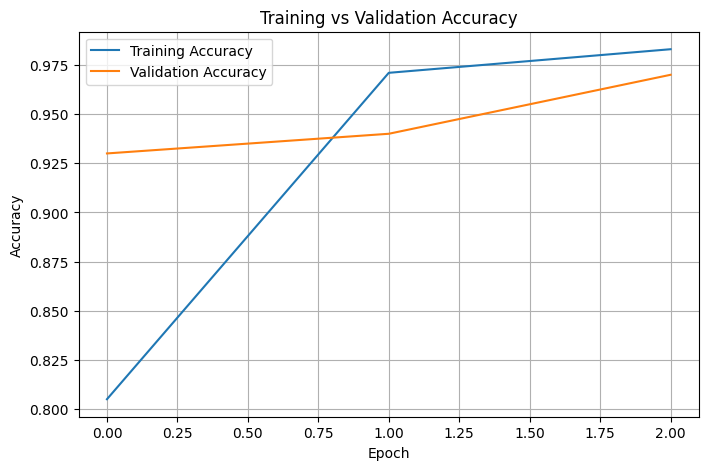

In [52]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

### Training Loss

Visualize training and validation loss to observe the learning behavior and identify signs of overfitting.

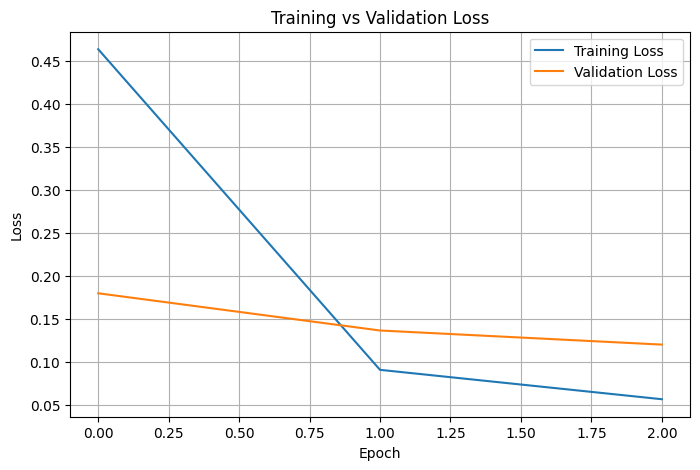

In [53]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

### Save the Trained Model

Save the trained VGG16 model for future inference without retraining.

In [54]:
model.save("cat_dog_vgg16.keras")

In [ ]:
from tensorflow.keras.models import load_model
loaded_model = load_model("cat_dog_vgg16.keras")
loaded_model.summary()

### Evaluate on the Test Dataset

Measure the final performance of the trained model using previously unseen test images.

In [55]:
loss, accuracy = model.evaluate(test_batch)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.9850 - loss: 0.0663
Test Loss: 0.06628815829753876
Test Accuracy: 0.9850000143051147
